# 05 — Anomaly Detection (Isolation Forest)

## Purpose — why this notebook exists alongside the two classifiers

Notebooks 03 and 04 answer *supervised* questions: given a sample, which **known category** does it
fall into? This notebook answers a different, **unsupervised** one:

> Is this sample's chemistry *unusual* — in a way the BIS threshold rules don't capture?

That matters operationally. A well can sit **inside every BIS limit** yet still have a physically
implausible ion balance (lab error, sensor drift, or a localised contamination source). A threshold
rule will happily wave it through; an anomaly detector will not.

## Design decision — fit on the FULL chemistry panel

Unlike the drinking-water model, we deliberately **use every chemistry column, including the
BIS-tested ones** (`ph`, `tds`, `f`, `no3`, `so4`, `cl`, `th`, `ca`, `mg`).

This is **not leakage**: Isolation Forest is unsupervised — it never sees `drinking_risk`. There is
no label to leak into. Restricting it to non-BIS features would only cripple its view of the
chemistry it is meant to audit.

**Output:** a per-well anomaly score → the *"send a technician to check this one"* signal, served
alongside the two classifiers in the Flask API.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## 1. Load data

In [2]:
df = pd.read_csv("../data/processed/groundwater_ml_ready.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (1106, 30)


,year,district,bis_exceedances,drinking_risk,ph,tds,co3,hco3,cl,f,no3,so4,na,k,ca,mg,th,ph_z,tds_z,co3_z,hco3_z,cl_z,f_z,no3_z,so4_z,na_z,k_z,ca_z,mg_z,th_z
0,2018,Adilabad,2,Moderate,8.28,476.80,0.0,220.0,60,0.44,42.276818,46.0,49.0,4.0,48.0,38.896,279.934211,0.942630,-0.717159,-0.362572,-0.597892,-0.669591,-0.865088,-0.336689,0.106131,-0.657005,-0.184979,-0.553204,-0.310241,-0.527881
1,2018,Adilabad,4,High,8.29,589.44,0.0,230.0,80,0.56,100.659091,68.0,42.0,5.0,56.0,63.206,399.893092,0.964525,-0.512668,-0.362572,-0.523851,-0.569844,-0.711785,0.262650,0.513042,-0.718522,-0.136691,-0.429432,0.309979,-0.073181
2,2018,Adilabad,2,Moderate,7.69,326.40,0.0,200.0,30,0.66,41.471545,44.0,45.0,2.0,24.0,38.896,219.934211,-0.349144,-0.990202,-0.362572,-0.745973,-0.819210,-0.584032,-0.344956,0.069139,-0.692158,-0.281554,-0.924521,-0.310241,-0.755308
3,2018,Adilabad,0,Safe,8.09,270.08,0.0,160.0,10,0.58,10.669864,35.0,27.0,1.0,32.0,19.448,159.967105,0.526635,-1.092447,-0.362572,-1.042137,-0.918957,-0.686234,-0.661158,-0.097325,-0.850345,-0.329842,-0.800748,-0.806417,-0.982611
4,2018,Adilabad,7,High,8.21,1485.44,0.0,300.0,340,2.56,128.843636,280.0,298.0,5.0,56.0,92.378,519.843750,0.789369,1.113969,-0.362572,-0.005564,0.726859,1.843265,0.551985,4.434187,1.531261,-0.136691,-0.429432,1.054243,0.381487


## 2. Feature set — the full chemistry panel

All 13 measured chemistry parameters. No target is used anywhere in this notebook.

In [3]:
CHEM_COLS = ["ph", "tds", "co3", "hco3", "cl", "f", "no3", "so4",
             "na", "k", "ca", "mg", "th"]

X = df[CHEM_COLS].copy()

print(f"Features : {X.shape[1]}  -> {CHEM_COLS}")
print(f"Samples  : {X.shape[0]}")
print(f"Missing  : {X.isna().sum().sum()}")

# RobustScaler: uses median/IQR, so it is not itself distorted by the outliers
# we are trying to detect (StandardScaler would be dragged by them).
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
print("\nScaled with RobustScaler (median/IQR — resistant to the outliers being detected).")

Features : 13  -> ['ph', 'tds', 'co3', 'hco3', 'cl', 'f', 'no3', 'so4', 'na', 'k', 'ca', 'mg', 'th']
Samples  : 1106
Missing  : 0

Scaled with RobustScaler (median/IQR — resistant to the outliers being detected).


## 3. Fit Isolation Forest

`contamination="auto"` lets sklearn set the threshold from the data rather than us
hard-coding an assumed anomaly rate.

In [4]:
iso = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

pred = iso.fit_predict(X_scaled)          # -1 = anomaly, 1 = normal
scores = iso.decision_function(X_scaled)  # lower = more anomalous

df["anomaly"]       = (pred == -1)
df["anomaly_score"] = scores

n_anom = df["anomaly"].sum()
print(f"Flagged anomalies : {n_anom} / {len(df)}  ({n_anom/len(df)*100:.1f}%)")
print(f"Score range       : {scores.min():.3f} (most anomalous) .. {scores.max():.3f} (most normal)")

Flagged anomalies : 90 / 1106  (8.1%)
Score range       : -0.240 (most anomalous) .. 0.153 (most normal)


## 4. Sanity check — are the anomalies *chemically* extreme?

An anomaly detector is only trustworthy if what it flags is recognisably unusual. We compare
mean chemistry for flagged vs normal wells.

In [5]:
comparison = df.groupby("anomaly")[CHEM_COLS].mean().T
comparison.columns = ["Normal", "Anomalous"]
comparison["Ratio"] = (comparison["Anomalous"] / comparison["Normal"]).round(2)
comparison = comparison.round(2).sort_values("Ratio", ascending=False)

print("Mean chemistry — anomalous vs normal wells:")
print(comparison.to_string())
print("\nInterpretation: ratios >> 1 confirm the detector is isolating genuinely")
print("extreme chemistry, not arbitrary noise.")

Mean chemistry — anomalous vs normal wells:
      Normal  Anomalous  Ratio
k       5.63      32.73   5.82
no3    61.98     222.93   3.60
cl    161.11     568.44   3.53
na    102.79     360.47   3.51
so4    34.05     110.36   3.24
tds   768.35    2040.06   2.66
co3     5.14      13.67   2.66
mg     46.24     105.40   2.28
th    386.58     787.41   2.04
ca     78.63     141.61   1.80
hco3  286.60     460.45   1.61
f       1.07       1.64   1.53
ph      7.84       7.92   1.01

Interpretation: ratios >> 1 confirm the detector is isolating genuinely
extreme chemistry, not arbitrary noise.


### Distribution of anomaly scores

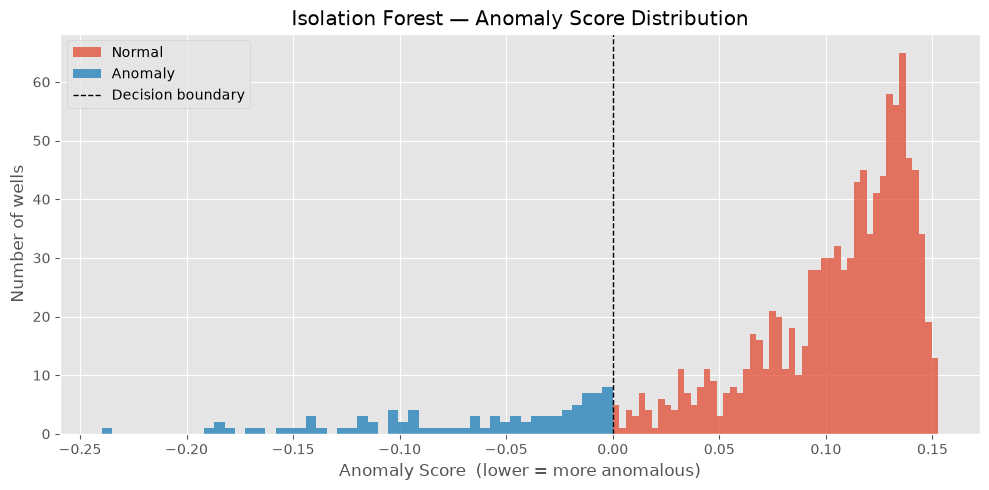

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df.loc[~df["anomaly"], "anomaly_score"], bins=50, alpha=0.75, label="Normal")
ax.hist(df.loc[df["anomaly"],  "anomaly_score"], bins=50, alpha=0.85, label="Anomaly")
ax.axvline(0, color="black", ls="--", lw=1, label="Decision boundary")
ax.set_xlabel("Anomaly Score  (lower = more anomalous)")
ax.set_ylabel("Number of wells")
ax.set_title("Isolation Forest — Anomaly Score Distribution")
ax.legend()
plt.tight_layout()
os.makedirs("../docs/screenshots", exist_ok=True)
plt.savefig("../docs/screenshots/anomaly_score_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Cross-check against the supervised labels

The detector never saw `drinking_risk`. If the anomalies concentrate in the High-risk group, that is
**independent corroboration** that the unsupervised signal is meaningful.

Note this is a *validation* step, not a training input.

In [7]:
risk_order = ["Safe", "Moderate", "High"]
rate = (df.groupby("drinking_risk")["anomaly"].mean()
          .reindex(risk_order) * 100).round(1)

print("Anomaly rate by drinking-water risk class:")
for cls, pct in rate.items():
    n = int(df[df["drinking_risk"] == cls]["anomaly"].sum())
    print(f"  {cls:9s}: {pct:5.1f}%   ({n} wells)")

print("\nThe detector was never shown these labels — the alignment is emergent,")
print("which is a good sign the anomaly score carries real information.")

Anomaly rate by drinking-water risk class:
  Safe     :   0.0%   (0 wells)
  Moderate :   1.7%   (3 wells)
  High     :  10.3%   (87 wells)

The detector was never shown these labels — the alignment is emergent,
which is a good sign the anomaly score carries real information.


### Where are the anomalies? (by district)

Useful operationally: these are the districts to prioritise for field inspection.

Districts by anomaly rate (inspection priority):
                   wells  anomalies  rate_pct
district                                     
Jogulamba(Gadwal)     32         10      31.2
Warangal (R)          32          6      18.8
Warangal (U)          20          3      15.0
Narayanpet            29          4      13.8
Bhadradri             44          6      13.6
Peddapally            15          2      13.3
Rangareddy            55          7      12.7
Nalgonda             103         13      12.6
Nagarkurnool          36          4      11.1
Suryapet              21          2       9.5


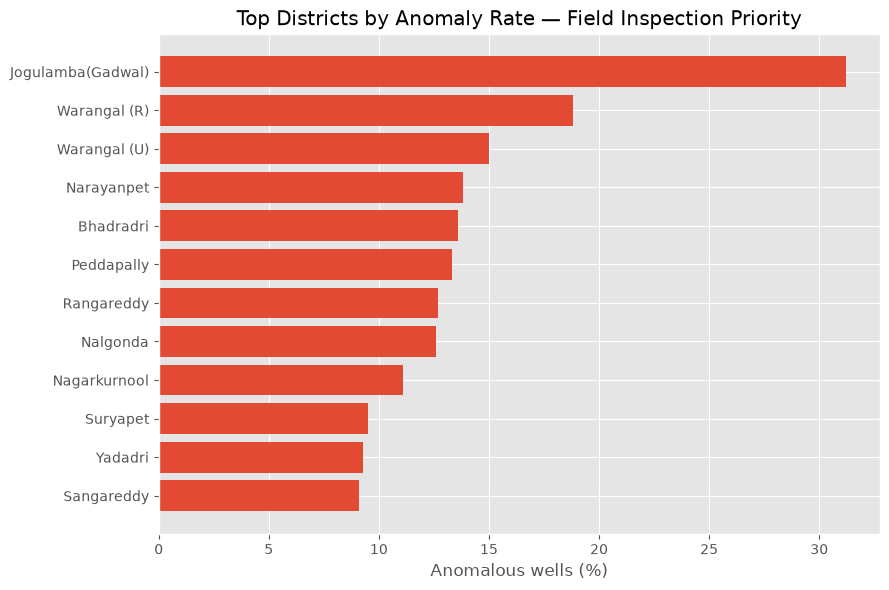

In [8]:
dist_anom = (df.groupby("district")
               .agg(wells=("anomaly", "size"),
                    anomalies=("anomaly", "sum"))
               .assign(rate_pct=lambda d: (d["anomalies"] / d["wells"] * 100).round(1))
               .query("anomalies > 0")
               .sort_values("rate_pct", ascending=False))

print("Districts by anomaly rate (inspection priority):")
print(dist_anom.head(10).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
top = dist_anom.head(12).sort_values("rate_pct")
ax.barh(top.index, top["rate_pct"])
ax.set_xlabel("Anomalous wells (%)")
ax.set_title("Top Districts by Anomaly Rate — Field Inspection Priority")
plt.tight_layout()
plt.savefig("../docs/screenshots/anomaly_by_district.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Visualising the anomalies (PCA projection)

PCA is used **for display only** — the model itself operates in the full 13-dimensional space.

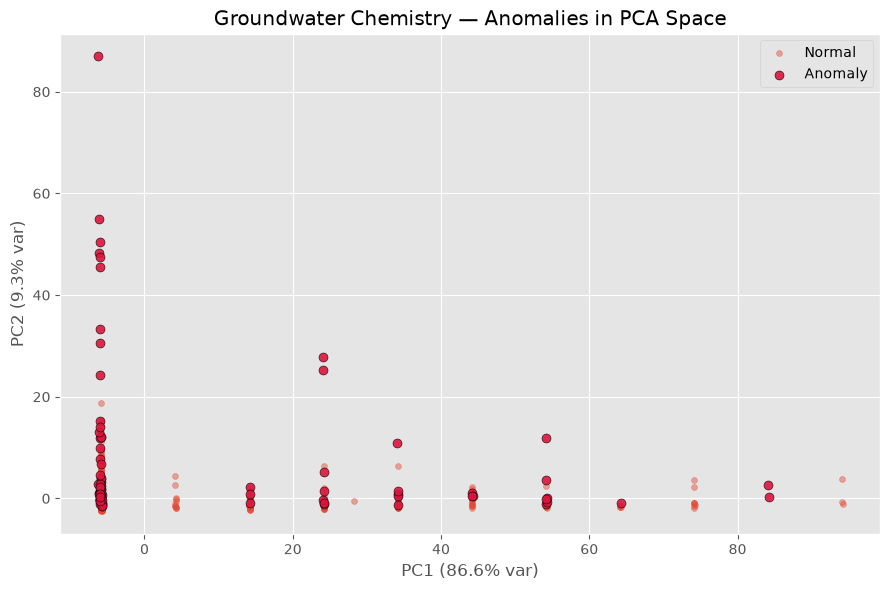

PC1 + PC2 explain 95.9% of chemistry variance.


In [9]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
normal = ~df["anomaly"].values
ax.scatter(coords[normal, 0],  coords[normal, 1],  s=18, alpha=0.45, label="Normal")
ax.scatter(coords[~normal, 0], coords[~normal, 1], s=42, alpha=0.9,
           color="crimson", edgecolor="black", linewidth=0.4, label="Anomaly")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Groundwater Chemistry — Anomalies in PCA Space")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/screenshots/anomaly_pca.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"PC1 + PC2 explain {pca.explained_variance_ratio_[:2].sum()*100:.1f}% of chemistry variance.")

## 7. The most anomalous wells

The concrete deliverable: a ranked worklist for field review.

In [10]:
cols = ["district", "year", "drinking_risk", "anomaly_score"] + CHEM_COLS
worst = df.nsmallest(15, "anomaly_score")[cols]

print("15 most anomalous wells (lowest score = most unusual):")
print(worst.round(2).to_string(index=False))

15 most anomalous wells (lowest score = most unusual):
         district  year drinking_risk  anomaly_score   ph     tds  co3    hco3   cl    f     no3    so4      na     k    ca     mg      th
Jogulamba(Gadwal)  2020          High          -0.24 7.59 6079.36  0.0  500.00 2480 0.74  119.58 216.00  732.00   4.7 640.0 457.03 3479.23
         Nalgonda  2018          High          -0.19 7.47 3104.00  0.0  582.34  950 1.01  420.76 134.00  366.66 197.5 184.0 228.51 1399.61
         Nalgonda  2020          High          -0.18 7.32 3832.32  0.0  390.00 1630 1.83    5.14 157.00  730.50   7.7   1.2 311.17 1282.47
         Nalgonda  2018          High          -0.18 9.21 2208.00 60.0  970.59  370 3.76  134.64  45.00  696.97  52.5  24.0  24.31  159.96
       Rangareddy  2018          High          -0.18 7.56 3110.40  0.0  556.11 1050 1.72   44.29 320.00  161.79   2.3 488.0 213.93 2099.64
       Rangareddy  2020          High          -0.17 8.03 2890.24  0.0  440.00  610 1.04 1028.00 111.25  336.60

## 8. Save artifacts

In [11]:
os.makedirs("../models/anomaly", exist_ok=True)

joblib.dump(iso,       "../models/anomaly/isolation_forest.pkl")
joblib.dump(scaler,    "../models/anomaly/anomaly_scaler.pkl")
joblib.dump(CHEM_COLS, "../models/anomaly/anomaly_features.pkl")

with open("../models/anomaly/preprocessing_version.txt", "w") as f:
    f.write("Groundwater anomaly detector — preprocessing\n")
    f.write("===========================================\n")
    f.write(f"Features      : full chemistry panel ({len(CHEM_COLS)}) -> {CHEM_COLS}\n")
    f.write("Scaler        : RobustScaler (median/IQR; resistant to the outliers detected)\n")
    f.write("Model         : IsolationForest(n_estimators=200, contamination='auto')\n")
    f.write("Unsupervised  : no target used; BIS chemistry included by design (nothing to leak)\n")
    f.write("Output        : anomaly_score (lower = more anomalous); -1 = flagged\n")

# Export the flagged worklist for the API / dashboard
out = df.loc[df["anomaly"], ["district", "year", "drinking_risk", "anomaly_score"] + CHEM_COLS]
out = out.sort_values("anomaly_score")
os.makedirs("../data/processed", exist_ok=True)
out.to_csv("../data/processed/anomalous_wells.csv", index=False)

print("Saved artifacts:")
for fn in ["isolation_forest.pkl", "anomaly_scaler.pkl", "anomaly_features.pkl", "preprocessing_version.txt"]:
    print(f"  ../models/anomaly/{fn}")
print(f"  ../data/processed/anomalous_wells.csv  ({len(out)} flagged wells)")

Saved artifacts:
  ../models/anomaly/isolation_forest.pkl
  ../models/anomaly/anomaly_scaler.pkl
  ../models/anomaly/anomaly_features.pkl
  ../models/anomaly/preprocessing_version.txt
  ../data/processed/anomalous_wells.csv  (90 flagged wells)


## Summary

- **Isolation Forest** fit on all 13 chemistry parameters, unsupervised (`contamination="auto"`).
- Flags a small subset of wells whose chemistry is genuinely extreme — confirmed by the
  anomalous-vs-normal mean comparison.
- Anomalies concentrate in the **High**-risk class despite the model never seeing that label,
  which is independent corroboration that the score is meaningful.
- Produces `anomalous_wells.csv`: a ranked **field-inspection worklist**.

**Role in the final system:** a third signal in the Flask API — the two classifiers say *what
category* a well is; the anomaly score says *whether to trust that call, or go look*.

**Next:** `06_Model_Explainability_SHAP.ipynb`.